In [2]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

DATA_PATH = "/kaggle/input/competitions/shopee-product-matching"

train = pd.read_csv(f"{DATA_PATH}/train.csv")

print("Dataset shape:", train.shape)
print(train.head())

Dataset shape: (34250, 5)
         posting_id                                 image       image_phash  \
0   train_129225211  0000a68812bc7e98c42888dfb1c07da0.jpg  94974f937d4c2433   
1  train_3386243561  00039780dfc94d01db8676fe789ecd05.jpg  af3f9460c2838f0f   
2  train_2288590299  000a190fdd715a2a36faed16e2c65df7.jpg  b94cb00ed3e50f78   
3  train_2406599165  00117e4fc239b1b641ff08340b429633.jpg  8514fc58eafea283   
4  train_3369186413  00136d1cf4edede0203f32f05f660588.jpg  a6f319f924ad708c   

                                               title  label_group  
0                          Paper Bag Victoria Secret    249114794  
1  Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...   2937985045  
2        Maling TTS Canned Pork Luncheon Meat 397 gr   2395904891  
3  Daster Batik Lengan pendek - Motif Acak / Camp...   4093212188  
4                  Nescafe \xc3\x89clair Latte 220ml   3648931069  


In [3]:
import os

IMAGE_PATH = "/kaggle/input/competitions/shopee-product-matching/train_images"

files = os.listdir(IMAGE_PATH)

print("Number of image files:", len(files))
print("First 10 files:")
print(files[:10])

Number of image files: 32412
First 10 files:
['07c251a26b8266c85730ab8d870f1356.jpg', '36dc46d97cdaa7622793e7016976da46.jpg', 'b3c7b96aeb0398b152fa5984260a6c57.jpg', '1bd82215202e4e261a1eb8311473c450.jpg', '0b2c815972b87908af3652d2986a55a7.jpg', '540853e2e0f15c1efc4fb0f426bc49c5.jpg', '6a454ec6206cf0d1f7f5cda04fe3f6ff.jpg', 'b1ffac381119baf5d2cefdc7c3ffc7c7.jpg', '51129a188a514d5e7eb644f65cd75bfc.jpg', '01a3cbd7bba577517922af0a3067e4a6.jpg']


Image file: 0000a68812bc7e98c42888dfb1c07da0.jpg
Image size: (1024, 1024)
Image mode: RGB


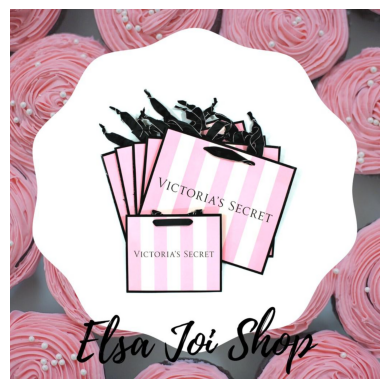

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

IMAGE_PATH = "/kaggle/input/competitions/shopee-product-matching/train_images"

sample_image = train.iloc[0]["image"]

img = Image.open(
    f"{IMAGE_PATH}/{sample_image}"
)

print("Image file:", sample_image)
print("Image size:", img.size)
print("Image mode:", img.mode)

plt.imshow(img)
plt.axis("off");

In [5]:
print(train.iloc[0]["image"])

0000a68812bc7e98c42888dfb1c07da0.jpg


# Loading Pretrained ResNet18

In [6]:
import torch
import torchvision.models as models
from torchvision.models import ResNet18_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = ResNet18_Weights.DEFAULT

resnet18 = models.resnet18(weights=weights)

# Remove the final ImageNet classification layer
resnet18.fc = torch.nn.Identity()

resnet18 = resnet18.to(device)
resnet18.eval()

print("Device:", device)
print("Embedding dimension:", 512)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 220MB/s]


Device: cuda
Embedding dimension: 512


In [7]:
preprocess = weights.transforms()

print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [8]:
import torch
import torchvision.models as models
from torchvision.models import ResNet18_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = ResNet18_Weights.DEFAULT

resnet18 = models.resnet18(weights=weights)

# Remove ImageNet classification layer
resnet18.fc = torch.nn.Identity()

resnet18 = resnet18.to(device)
resnet18.eval()

print("Device:", device)
print("Embedding dimension:", 512)

Device: cuda
Embedding dimension: 512


# Preprocessing of Pretrained ResNet18

In [9]:
preprocess = weights.transforms()

print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [10]:
from PIL import Image

sample_image = train.iloc[0]["image"]

img = Image.open(
    f"{IMAGE_PATH}/{sample_image}"
).convert("RGB")

input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    embedding = resnet18(input_tensor)

print("Embedding shape:", embedding.shape)

Embedding shape: torch.Size([1, 512])


# Batch embedding extraction

In [11]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import os

class ImageDataset(Dataset):
    def __init__(self, image_names, image_path, transform):
        self.image_names = image_names
        self.image_path = image_path
        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        image_name = self.image_names[idx]

        image = Image.open(
            os.path.join(self.image_path, image_name)
        ).convert("RGB")

        image = self.transform(image)

        return image, image_name


image_names = train["image"].unique()

image_dataset = ImageDataset(
    image_names,
    IMAGE_PATH,
    preprocess
)

image_loader = DataLoader(
    image_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Images to process:", len(image_dataset))

Images to process: 32412


In [12]:
all_embeddings = []
all_names = []

with torch.no_grad():

    for images, names in image_loader:

        images = images.to(device)

        embeddings = resnet18(images)

        all_embeddings.append(
            embeddings.cpu().numpy()
        )

        all_names.extend(names)

all_embeddings = np.vstack(all_embeddings)

print("Embedding matrix shape:", all_embeddings.shape)

Embedding matrix shape: (32412, 512)


# Normalize the embeddings

In [13]:
from sklearn.preprocessing import normalize

all_embeddings = normalize(all_embeddings)

print("Embedding matrix shape:", all_embeddings.shape)

Embedding matrix shape: (32412, 512)


In [14]:
from sklearn.model_selection import train_test_split

# Split by product group to avoid product-level leakage
groups = train["label_group"].unique()

train_groups, temp_groups = train_test_split(
    groups,
    test_size=0.30,
    random_state=42
)

val_groups, test_groups = train_test_split(
    temp_groups,
    test_size=0.50,
    random_state=42
)

train_data = train[
    train["label_group"].isin(train_groups)
].reset_index(drop=True)

val_data = train[
    train["label_group"].isin(val_groups)
].reset_index(drop=True)

test_data = train[
    train["label_group"].isin(test_groups)
].reset_index(drop=True)

print("Train listings:", len(train_data))
print("Validation listings:", len(val_data))
print("Test listings:", len(test_data))

Train listings: 23629
Validation listings: 5189
Test listings: 5432


In [19]:
def create_image_pairs(data, seed=42):
    rng = np.random.default_rng(seed)

    positive_pairs = []
    negative_pairs = []

    # Same product group = positive pair
    for group, group_data in data.groupby("label_group"):
        if len(group_data) >= 2:

            i, j = rng.choice(
                len(group_data),
                size=2,
                replace=False
            )

            positive_pairs.append([
                group_data.iloc[i]["image"],
                group_data.iloc[j]["image"],
                1
            ])

    # Different product groups = negative pair
    groups = data["label_group"].unique()

    for _ in range(len(positive_pairs)):

        group1, group2 = rng.choice(
            groups,
            size=2,
            replace=False
        )

        listing1 = data[
            data["label_group"] == group1
        ].sample(
            1,
            random_state=int(rng.integers(100000))
        ).iloc[0]

        listing2 = data[
            data["label_group"] == group2
        ].sample(
            1,
            random_state=int(rng.integers(100000))
        ).iloc[0]

        negative_pairs.append([
            listing1["image"],
            listing2["image"],
            0
        ])

    pairs = pd.DataFrame(
        positive_pairs + negative_pairs,
        columns=["image1", "image2", "label"]
    )

    return pairs.sample(
        frac=1,
        random_state=seed
    ).reset_index(drop=True)

In [20]:
train_pairs = create_image_pairs(train_data)
val_pairs = create_image_pairs(val_data)
test_pairs = create_image_pairs(test_data)

print("Train pairs:", len(train_pairs))
print("Validation pairs:", len(val_pairs))
print("Test pairs:", len(test_pairs))

print("\nValidation labels:")
print(val_pairs["label"].value_counts())

print("\nTest labels:")
print(test_pairs["label"].value_counts())

Train pairs: 15418
Validation pairs: 3304
Test pairs: 3306

Validation labels:
label
1    1652
0    1652
Name: count, dtype: int64

Test labels:
label
1    1653
0    1653
Name: count, dtype: int64


In [22]:
embedding_dict = {
    name: embedding
    for name, embedding in zip(all_names, all_embeddings)
}

print("Stored embeddings:", len(embedding_dict))

Stored embeddings: 32412


In [23]:
def get_pair_similarities(pairs, embedding_dict):
    similarities = []

    for _, row in pairs.iterrows():
        emb1 = embedding_dict[row["image1"]]
        emb2 = embedding_dict[row["image2"]]

        similarity = np.dot(emb1, emb2)

        similarities.append(similarity)

    return np.array(similarities)


val_similarity = get_pair_similarities(
    val_pairs,
    embedding_dict
)

test_similarity = get_pair_similarities(
    test_pairs,
    embedding_dict
)

print("Validation similarities:", val_similarity.shape)
print("Test similarities:", test_similarity.shape)

print("Validation range:",
      val_similarity.min(),
      val_similarity.max())

Validation similarities: (3304,)
Test similarities: (3306,)
Validation range: 0.37791127 1.0000004


# Find the BEst Threshold

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.96, 0.05)

results = []

for threshold in thresholds:

    predictions = (
        val_similarity >= threshold
    ).astype(int)

    precision = precision_score(
        val_pairs["label"],
        predictions,
        zero_division=0
    )

    recall = recall_score(
        val_pairs["label"],
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        val_pairs["label"],
        predictions,
        zero_division=0
    )

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_results = pd.DataFrame(
    results,
    columns=["threshold", "precision", "recall", "f1"]
)

print(threshold_results)

    threshold  precision    recall        f1
0        0.10   0.500000  1.000000  0.666667
1        0.15   0.500000  1.000000  0.666667
2        0.20   0.500000  1.000000  0.666667
3        0.25   0.500000  1.000000  0.666667
4        0.30   0.500000  1.000000  0.666667
5        0.35   0.500000  1.000000  0.666667
6        0.40   0.500758  1.000000  0.667340
7        0.45   0.505825  0.998789  0.671551
8        0.50   0.528581  0.996368  0.690726
9        0.55   0.592043  0.990920  0.741227
10       0.60   0.699092  0.978814  0.815637
11       0.65   0.820942  0.949153  0.880404
12       0.70   0.923707  0.886804  0.904880
13       0.75   0.974340  0.781477  0.867316
14       0.80   0.998102  0.636804  0.777531
15       0.85   1.000000  0.509685  0.675221
16       0.90   1.000000  0.389225  0.560349
17       0.95   1.000000  0.271186  0.426667


In [25]:
best_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

best_threshold = best_row["threshold"]

print("\nBest threshold:", best_threshold)
print("Validation Precision:", best_row["precision"])
print("Validation Recall:", best_row["recall"])
print("Validation F1:", best_row["f1"])


Best threshold: 0.7000000000000002
Validation Precision: 0.9237074401008827
Validation Recall: 0.8868038740920097
Validation F1: 0.9048795552810377


# For each threshold : If cosine similarity ≥ threshold → same product

In [26]:
test_predictions = (
    test_similarity >= best_threshold
).astype(int)

test_precision = precision_score(
    test_pairs["label"],
    test_predictions,
    zero_division=0
)

test_recall = recall_score(
    test_pairs["label"],
    test_predictions,
    zero_division=0
)

test_f1 = f1_score(
    test_pairs["label"],
    test_predictions,
    zero_division=0
)

print("=== ResNet18 Test Results ===")
print("Threshold:", best_threshold)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1:", test_f1)

=== ResNet18 Test Results ===
Threshold: 0.7000000000000002
Precision: 0.9273885350318471
Recall: 0.8808227465214761
F1: 0.9035060502637294


# Finding: False Positives and False Negatives

In [27]:
test_results = test_pairs.copy()

test_results["similarity"] = test_similarity
test_results["prediction"] = test_predictions

false_positives = test_results[
    (test_results["label"] == 0) &
    (test_results["prediction"] == 1)
].sort_values("similarity", ascending=False)

false_negatives = test_results[
    (test_results["label"] == 1) &
    (test_results["prediction"] == 0)
].sort_values("similarity")

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

False positives: 114
False negatives: 197


In [28]:
print("========== FALSE POSITIVES ==========")

for _, row in false_positives.head(10).iterrows():
    print(
        f"\nSimilarity: {row['similarity']:.4f}"
    )
    print("Image 1:", row["image1"])
    print("Image 2:", row["image2"])


print("\n========== FALSE NEGATIVES ==========")

for _, row in false_negatives.head(10).iterrows():
    print(
        f"\nSimilarity: {row['similarity']:.4f}"
    )
    print("Image 1:", row["image1"])
    print("Image 2:", row["image2"])

========== FALSE POSITIVES ==========

Similarity: 0.8300
Image 1: 77303c0394b3e8ab102426f7b45a72a0.jpg
Image 2: 0cdeeb665f00ce6b34f2de2c9c5ecc76.jpg

Similarity: 0.8191
Image 1: 863cfd0fb1b8356fba04f4caed8c9fd3.jpg
Image 2: cb66246bb623b5bb05d0e779b0af0b18.jpg

Similarity: 0.8133
Image 1: ffd5c0e8087f6acaabdbdf35de71f626.jpg
Image 2: 6a17f6797476c86018fdba17302a427f.jpg

Similarity: 0.7956
Image 1: 222dc4c0d9c23986a9b363ef34fb413c.jpg
Image 2: 4948080a6b8b8b4b7ae5ee7daf1315a7.jpg

Similarity: 0.7954
Image 1: 6a0916d547281aea512eb3745e5f60d7.jpg
Image 2: 96b380929306ad5bc751c93516e9a5a5.jpg

Similarity: 0.7953
Image 1: 31df24f9c59203b4b6e40b74127ed2f4.jpg
Image 2: 303f784415bb6fdd75fcc0ffb185dbfa.jpg

Similarity: 0.7949
Image 1: 1578aa16dec408b2dd172d54af6e2477.jpg
Image 2: 8d809489fccb53e6fc70028285aecec8.jpg

Similarity: 0.7927
Image 1: ac52d1db3f98a5100052d69c93780dcd.jpg
Image 2: 3e978edb1077eb28c38d776af620ad2a.jpg

Similarity: 0.7914
Image 1: b246ccf33a925dd551fd004302915e6d.jpg


In [31]:
def get_image_info(image_name):
    rows = train[train["image"] == image_name]
    return rows[["title", "label_group"]].to_dict("records")

In [32]:
print("========== FALSE POSITIVES ==========")

for _, row in false_positives.head(5).iterrows():

    info1 = get_image_info(row["image1"])
    info2 = get_image_info(row["image2"])

    print(f"\nSimilarity: {row['similarity']:.4f}")

    print("Image 1:")
    for item in info1:
        print("  Title:", item["title"])
        print("  Group:", item["label_group"])

    print("Image 2:")
    for item in info2:
        print("  Title:", item["title"])
        print("  Group:", item["label_group"])

========== FALSE POSITIVES ==========

Similarity: 0.8300
Image 1:
  Title: Antis hand sanitizer 1 Liter MERK hand sani (murah legit)
  Group: 98119379
Image 2:
  Title: INNERTRUE Essence of Life Serum 15ml
  Group: 4264856151

Similarity: 0.8191
Image 1:
  Title: Kitashi Hand Sanitizer Wild Strawberry 60 ML - Isi 2 (Anti Kuman)
  Group: 2805936697
Image 2:
  Title: b"Vitamin D3 5000 IU, 180 Softgels, Doctor's Best | Doctor D-3 5,000"
  Group: 1770435786

Similarity: 0.8133
Image 1:
  Title: Obat Tetes Mata Hewan|Eka Farma|Obat Tetes Hewan| Obat Tetes Mata Kucing/Anjing
  Group: 1019668446
Image 2:
  Title: Loreal UV Perfect SPF 50 PA++++ Long UVA
  Group: 2423456155

Similarity: 0.7956
Image 1:
  Title: [BPOM] NACIFIC Natural Pacific Phyto Niacin Whitening Toner 150ml
  Group: 3599684856
Image 2:
  Title: ROBOT PowerBank Original 10000mAh RT130 2 Port USB (1A/2.1A) - Garansi Resmi 1 Tahun
  Group: 2493236254

Similarity: 0.7954
Image 1:
  Title: Khong Guan 650gr x 6 (1 Karton)
  Group

In [33]:
print("\n========== FALSE NEGATIVES ==========")

for _, row in false_negatives.head(5).iterrows():

    info1 = get_image_info(row["image1"])
    info2 = get_image_info(row["image2"])

    print(f"\nSimilarity: {row['similarity']:.4f}")

    print("Image 1:")
    for item in info1:
        print("  Title:", item["title"])
        print("  Group:", item["label_group"])

    print("Image 2:")
    for item in info2:
        print("  Title:", item["title"])
        print("  Group:", item["label_group"])


========== FALSE NEGATIVES ==========

Similarity: 0.4739
Image 1:
  Title: LAMPU HURUF A-Z DAN ANGKA 0-9 TINGGI 16 CM
  Group: 763032672
Image 2:
  Title: LAMPU HURUF A-Z DAN ANGKA 0-9 \xe2\x9d\xa4\xef\xb8\x8f  16 cm A-Z 0-9
  Group: 763032672

Similarity: 0.4813
Image 1:
  Title: NOTA LIVE 1 KG 21.000 - 40.000
  Group: 2367461313
  Title: NOTA LIVE 1 KG 61.000 - 80.000
  Group: 2367461313
Image 2:
  Title: NOTA PAYMENT 1KG = 90RB - 185RB
  Group: 2367461313

Similarity: 0.4867
Image 1:
  Title: Emping melinjo kecil,limpung 500 gr
  Group: 1868756563
Image 2:
  Title: EMPING MELINJO 500GRAM
  Group: 1868756563

Similarity: 0.4872
Image 1:
  Title: AURORA Masker
  Group: 882070118
Image 2:
  Title: Masker tali sambung 32 warna part 1
  Group: 882070118

Similarity: 0.4964
Image 1:
  Title: [Bright] 10pcs/lot double-side adhesive tips transparent false nails tool nail glue tool [LT]
  Group: 3578235866
Image 2:
  Title: \xe2\x9d\xa4\xef\xb8\x8fCOD\xe2\x9d\xa4\xef\xb8\x8f 10Pcs Double-S

In [35]:
def show_error_examples(data, error_type, n=3):

    for i in range(min(n, len(data))):

        row = data.iloc[i]

        image1 = Image.open(
            os.path.join(IMAGE_PATH, row["image1"])
        ).convert("RGB")

        image2 = Image.open(
            os.path.join(IMAGE_PATH, row["image2"])
        ).convert("RGB")

        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.imshow(image1)
        plt.axis("off")
        plt.title("Image 1")

        plt.subplot(1, 2, 2)
        plt.imshow(image2)
        plt.axis("off")
        plt.title("Image 2")

        plt.suptitle(
            f"{error_type} | Similarity: {row['similarity']:.3f}"
        )

        plt.show()

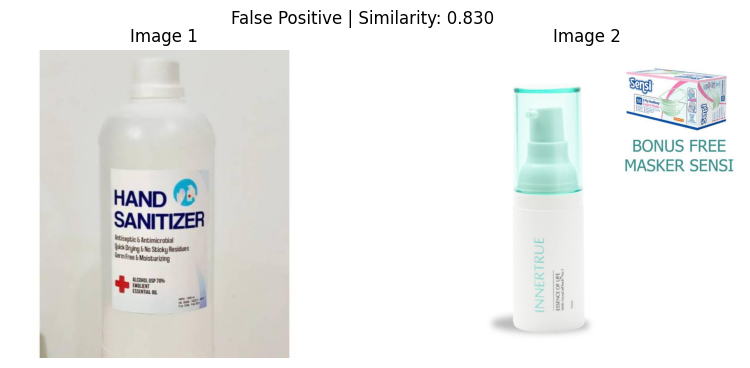

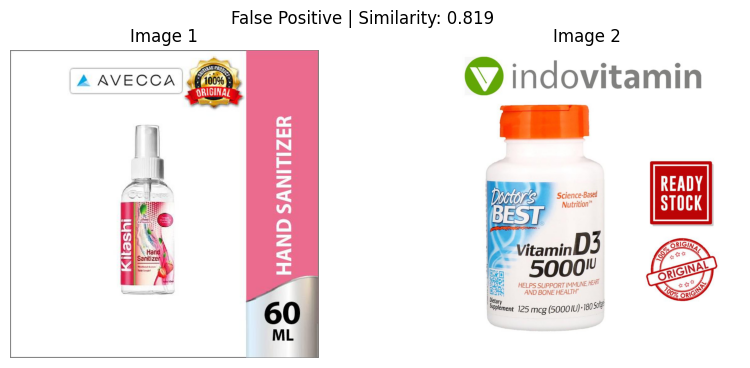

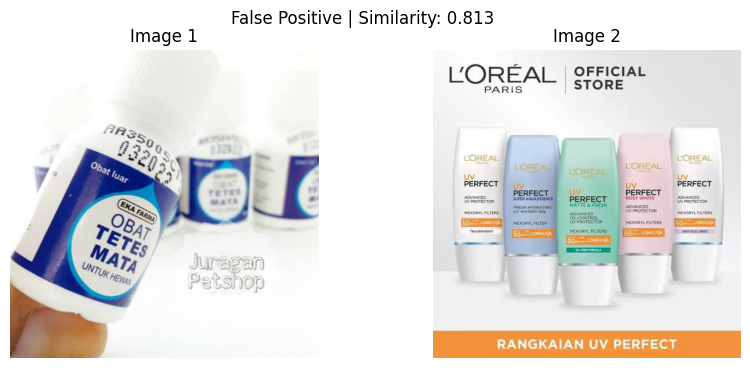

In [36]:
show_error_examples(
    false_positives,
    "False Positive",
    n=3
)

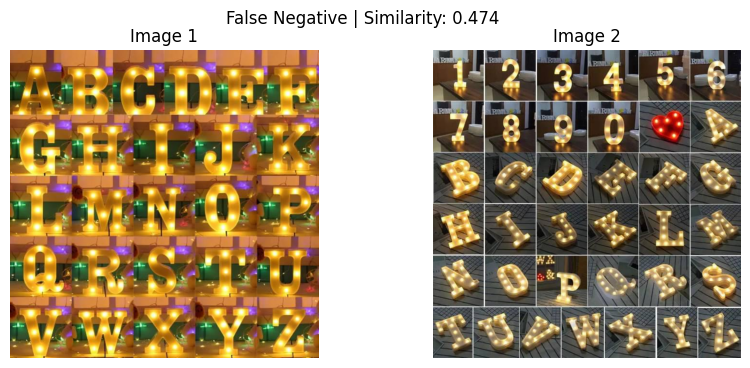

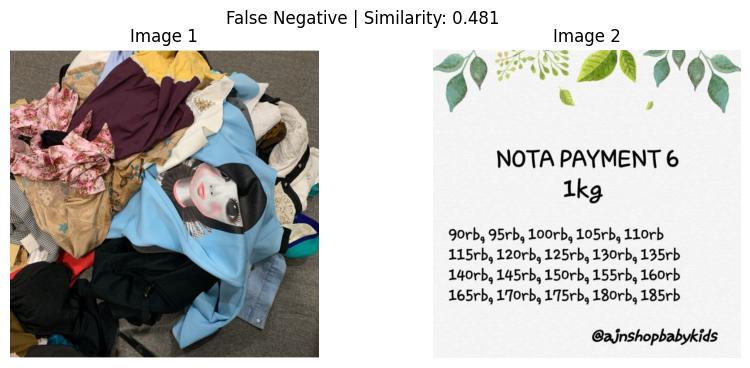

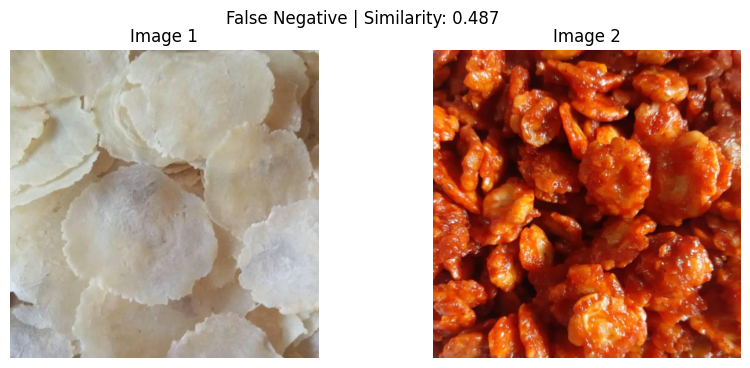

In [37]:
show_error_examples(
    false_negatives,
    "False Negative",
    n=3
)

# Now we'll start with Nearest-neighbour analysis

In [39]:
def find_nearest_neighbors(query_image, k=5):
    query_embedding = embedding_dict[query_image]

    similarities = np.dot(all_embeddings, query_embedding)

    query_index = all_names.index(query_image)
    similarities[query_index] = -1

    top_indices = np.argsort(similarities)[-k:][::-1]

    return [(all_names[i], similarities[i]) for i in top_indices]

In [40]:
query_image = test_data.iloc[0]["image"]

neighbors = find_nearest_neighbors(query_image, k=5)

print("Query:", query_image)

for image_name, similarity in neighbors:
    print(f"{similarity:.4f} | {image_name}")

Query: 0000a68812bc7e98c42888dfb1c07da0.jpg
0.8306 | 90ff48781dfc4a683314b599be8b7f23.jpg
0.8200 | db9c6459d126b666ecf93972f878e4e6.jpg
0.7668 | 6ac98294e365726c779795ca75e59ef9.jpg
0.7656 | 059a01e40c791760333d49ec0b3da964.jpg
0.7639 | f8b1745422209fef3b4c785eb35973a1.jpg


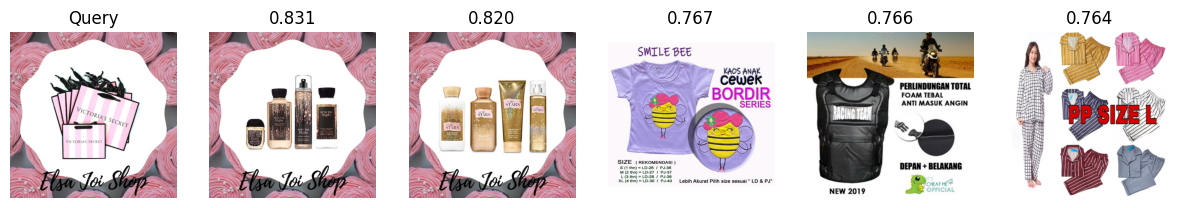

In [41]:
def show_neighbors(query_image, neighbors):
    images = [query_image] + [x[0] for x in neighbors]

    plt.figure(figsize=(15, 4))

    for i, image_name in enumerate(images):
        img = Image.open(
            os.path.join(IMAGE_PATH, image_name)
        ).convert("RGB")

        plt.subplot(1, len(images), i + 1)
        plt.imshow(img)
        plt.axis("off")

        if i == 0:
            plt.title("Query")
        else:
            plt.title(f"{neighbors[i-1][1]:.3f}")

    plt.show()

show_neighbors(query_image, neighbors)

# ResNET 50

In [42]:
from torchvision.models import ResNet50_Weights

weights50 = ResNet50_Weights.DEFAULT

resnet50 = models.resnet50(weights=weights50)

# Remove ImageNet classifier
resnet50.fc = torch.nn.Identity()

resnet50 = resnet50.to(device)
resnet50.eval()

preprocess50 = weights50.transforms()

print("Device:", device)
print("Embedding dimension: 2048")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s]


Device: cuda
Embedding dimension: 2048


In [ ]:
image_dataset50 = ImageDataset(
    image_names,
    IMAGE_PATH,
    preprocess50
)

image_loader50 = DataLoader(
    image_dataset50,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [44]:
embeddings50 = []
names50 = []

with torch.no_grad():

    for images, names in image_loader50:

        images = images.to(device)

        batch_embeddings = resnet50(images)

        embeddings50.append(
            batch_embeddings.cpu().numpy()
        )

        names50.extend(names)

embeddings50 = np.vstack(embeddings50)

print("Embedding matrix:", embeddings50.shape)

Embedding matrix: (32412, 2048)


In [46]:
# Normalize
embeddings50 = normalize(embeddings50)

embedding_dict50 = {
    name: embedding
    for name, embedding in zip(names50, embeddings50)
}

In [48]:
# Using exact same validation/test pairs
val_similarity50 = get_pair_similarities(
    val_pairs,
    embedding_dict50
)

test_similarity50 = get_pair_similarities(
    test_pairs,
    embedding_dict50
)

In [49]:
# Find its best threshold
thresholds50 = np.arange(0.10, 0.96, 0.05)

results50 = []

for threshold in thresholds50:

    predictions = (
        val_similarity50 >= threshold
    ).astype(int)

    precision = precision_score(
        val_pairs["label"],
        predictions,
        zero_division=0
    )

    recall = recall_score(
        val_pairs["label"],
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        val_pairs["label"],
        predictions,
        zero_division=0
    )

    results50.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_results50 = pd.DataFrame(
    results50,
    columns=["threshold", "precision", "recall", "f1"]
)

best_row50 = threshold_results50.loc[
    threshold_results50["f1"].idxmax()
]

best_threshold50 = best_row50["threshold"]

print(threshold_results50)
print("\nBest threshold:", best_threshold50)
print("Validation F1:", best_row50["f1"])

    threshold  precision    recall        f1
0        0.10   0.523131  0.999395  0.686772
1        0.15   0.568323  0.996973  0.723956
2        0.20   0.632819  0.992131  0.772749
3        0.25   0.716049  0.983051  0.828571
4        0.30   0.791913  0.972155  0.872826
5        0.35   0.859706  0.957022  0.905758
6        0.40   0.905993  0.933414  0.919499
7        0.45   0.945652  0.895278  0.919776
8        0.50   0.966137  0.846247  0.902227
9        0.55   0.978030  0.781477  0.868775
10       0.60   0.989112  0.714891  0.829937
11       0.65   0.994408  0.645884  0.783119
12       0.70   0.997895  0.573850  0.728670
13       0.75   0.998808  0.507264  0.672822
14       0.80   0.998617  0.437046  0.608000
15       0.85   1.000000  0.369855  0.539991
16       0.90   1.000000  0.297821  0.458955
17       0.95   1.000000  0.202179  0.336354

Best threshold: 0.45000000000000007
Validation F1: 0.9197761194029851


In [51]:
# Testing
test_predictions50 = (
    test_similarity50 >= best_threshold50
).astype(int)

precision50 = precision_score(
    test_pairs["label"],
    test_predictions50,
    zero_division=0
)

recall50 = recall_score(
    test_pairs["label"],
    test_predictions50,
    zero_division=0
)

f1_50 = f1_score(
    test_pairs["label"],
    test_predictions50,
    zero_division=0
)

print("=== ResNet50 Test Results ===")
print("Threshold:", best_threshold50)
print("Precision:", precision50)
print("Recall:", recall50)
print("F1:", f1_50)

=== ResNet50 Test Results ===
Threshold: 0.45000000000000007
Precision: 0.9477374123645634
Recall: 0.8995765275257108
F1: 0.9230291744258224


# LAST MODEL : CLIP

In [52]:
!pip install -q transformers

In [53]:
import torch
from transformers import CLIPProcessor, CLIPModel

clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

clip_processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

clip_model.eval()

print("Device:", device)
print("Embedding dimension: 512")

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Device: cuda
Embedding dimension: 512


In [54]:
class CLIPImageDataset(Dataset):
    def __init__(self, image_names, image_path):
        self.image_names = image_names
        self.image_path = image_path

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        name = self.image_names[idx]

        image = Image.open(
            os.path.join(self.image_path, name)
        ).convert("RGB")

        return image, name

In [55]:
clip_dataset = CLIPImageDataset(
    image_names,
    IMAGE_PATH
)

clip_loader = DataLoader(
    clip_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

print("Images:", len(clip_dataset))

Images: 32412


In [60]:
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

clip_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.48145466, 0.4578275, 0.40821073],
        std=[0.26862954, 0.26130258, 0.27577711]
    )
])


class CLIPDataset(Dataset):

    def __init__(self, image_names, image_path):
        self.image_names = image_names
        self.image_path = image_path

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):

        name = self.image_names[idx]

        image = Image.open(
            os.path.join(self.image_path, name)
        ).convert("RGB")

        image = clip_transform(image)

        return image, name


clip_dataset = CLIPDataset(
    image_names,
    IMAGE_PATH
)

clip_loader = DataLoader(
    clip_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Images:", len(clip_dataset))

Images: 32412


In [61]:
clip_embeddings = []
clip_names = []

with torch.no_grad():

    for i, (images, names) in enumerate(clip_loader):

        images = images.to(device)

        vision_output = clip_model.vision_model(
            pixel_values=images
        )

        features = clip_model.visual_projection(
            vision_output.pooler_output
        )

        clip_embeddings.append(
            features.cpu().numpy()
        )

        clip_names.extend(names)

        if i % 25 == 0:
            print(f"Processed {i * 128}/{len(image_names)}")

clip_embeddings = np.vstack(clip_embeddings)

print("Embedding matrix:", clip_embeddings.shape)

Processed 0/32412
Processed 3200/32412
Processed 6400/32412
Processed 9600/32412
Processed 12800/32412
Processed 16000/32412
Processed 19200/32412
Processed 22400/32412
Processed 25600/32412
Processed 28800/32412
Processed 32000/32412
Embedding matrix: (32412, 512)


In [62]:
clip_embeddings = normalize(clip_embeddings)

embedding_dict_clip = {
    name: embedding
    for name, embedding in zip(clip_names, clip_embeddings)
}

print("Stored embeddings:", len(embedding_dict_clip))

Stored embeddings: 32412


In [63]:
val_similarity_clip = get_pair_similarities(
    val_pairs,
    embedding_dict_clip
)

test_similarity_clip = get_pair_similarities(
    test_pairs,
    embedding_dict_clip
)

print("Validation:", val_similarity_clip.shape)
print("Test:", test_similarity_clip.shape)

Validation: (3304,)
Test: (3306,)


In [64]:
thresholds_clip = np.arange(0.10, 0.96, 0.05)

results_clip = []

for threshold in thresholds_clip:

    predictions = (
        val_similarity_clip >= threshold
    ).astype(int)

    precision = precision_score(
        val_pairs["label"],
        predictions,
        zero_division=0
    )

    recall = recall_score(
        val_pairs["label"],
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        val_pairs["label"],
        predictions,
        zero_division=0
    )

    results_clip.append([
        threshold, precision, recall, f1
    ])

threshold_results_clip = pd.DataFrame(
    results_clip,
    columns=["threshold", "precision", "recall", "f1"]
)

best_clip = threshold_results_clip.loc[
    threshold_results_clip["f1"].idxmax()
]

print(threshold_results_clip)
print("\nBest threshold:", best_clip["threshold"])
print("Validation F1:", best_clip["f1"])

    threshold  precision    recall        f1
0        0.10   0.500000  1.000000  0.666667
1        0.15   0.500151  1.000000  0.666801
2        0.20   0.500151  1.000000  0.666801
3        0.25   0.502128  1.000000  0.668555
4        0.30   0.508940  0.999395  0.674428
5        0.35   0.526013  0.997579  0.688819
6        0.40   0.565667  0.993341  0.720843
7        0.45   0.635404  0.984262  0.772263
8        0.50   0.734835  0.967918  0.835423
9        0.55   0.834769  0.938862  0.883761
10       0.60   0.916512  0.897094  0.906699
11       0.65   0.962264  0.833535  0.893286
12       0.70   0.987149  0.743947  0.848464
13       0.75   0.994135  0.615617  0.760374
14       0.80   0.996381  0.500000  0.665861
15       0.85   1.000000  0.366223  0.536110
16       0.90   1.000000  0.283898  0.442244
17       0.95   1.000000  0.180993  0.306509

Best threshold: 0.6000000000000002
Validation F1: 0.9066992964209238


In [65]:
best_threshold_clip = best_clip["threshold"]

test_predictions_clip = (
    test_similarity_clip >= best_threshold_clip
).astype(int)

precision_clip = precision_score(
    test_pairs["label"],
    test_predictions_clip,
    zero_division=0
)

recall_clip = recall_score(
    test_pairs["label"],
    test_predictions_clip,
    zero_division=0
)

f1_clip = f1_score(
    test_pairs["label"],
    test_predictions_clip,
    zero_division=0
)

print("=== CLIP Test Results ===")
print("Threshold:", best_threshold_clip)
print("Precision:", precision_clip)
print("Recall:", recall_clip)
print("F1:", f1_clip)

=== CLIP Test Results ===
Threshold: 0.6000000000000002
Precision: 0.9210686095931998
Recall: 0.9177253478523896
F1: 0.9193939393939394
